In [1]:
import os
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

print("✅ Setup complete")

✅ Setup complete


In [2]:
def compute_quality(img_path):
    img = cv2.imread(str(img_path))
    if img is None:
        return None, None, None
    
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    brightness = np.mean(gray)
    contrast = np.std(gray)
    sharpness = cv2.Laplacian(gray, cv2.CV_64F).var()
    
    return brightness, contrast, sharpness


def coeff_var(x):
    return np.std(x) / (np.mean(x) + 1e-6)

In [3]:
from pathlib import Path

BASE = Path("/kaggle/input/datasets/samriddhibagchi/unified-retinal-lesion-dataset")
IMG_PATH = BASE / "unified_shuffled" / "images"
MASK_PATH = BASE / "unified_shuffled" / "masks"

def unified_coverage(mask_path):
    mask = np.load(mask_path)  # (4, H, W)
    combined = (mask.max(axis=0) > 0).astype(np.uint8)
    return np.sum(combined) / combined.size

rows = []
for f in tqdm(os.listdir(MASK_PATH)):
    cov = unified_coverage(MASK_PATH / f)
    rows.append(cov)

unified_cov = pd.Series(rows)

print("📊 Unified Coverage CV:", coeff_var(unified_cov))

100%|██████████| 1106/1106 [00:18<00:00, 58.28it/s]

📊 Unified Coverage CV: 2.4621011488643143


In [4]:
from pathlib import Path

IDRID_MASK = Path("/kaggle/input/datasets/samriddhibagchi/indian-diabetic-retinopathy-image-dataset-idrid/A. Segmentation/A. Segmentation/2. All Segmentation Groundtruths/a. Training Set")

covs = []

for root, _, files in os.walk(IDRID_MASK):
    for f in files:
        p = os.path.join(root, f)
        mask = cv2.imread(p, 0)
        if mask is None:
            continue
        
        cov = np.sum(mask > 0) / mask.size
        covs.append(cov)

idrid_cov = pd.Series(covs)

print("📊 IDRiD Coverage CV:", coeff_var(idrid_cov))

📊 IDRiD Coverage CV: 1.4820561797304117


In [5]:
from pathlib import Path

EX_ANN = Path("/kaggle/input/datasets/samriddhibagchi/e-ophtha-diabetic-retinopathy-datasets-ex-ma/e_ophtha_EX/e_optha_EX/Annotation_EX")

covs = []

for root, _, files in os.walk(EX_ANN):
    for f in files:
        p = os.path.join(root, f)
        mask = cv2.imread(p, 0)
        if mask is None:
            continue
        
        cov = np.sum(mask > 0) / mask.size
        covs.append(cov)

eophtha_cov = pd.Series(covs)

print("📊 E-Ophtha Coverage CV:", coeff_var(eophtha_cov))

📊 E-Ophtha Coverage CV: 1.3379356615060352


In [6]:
from pathlib import Path
import os
import pandas as pd
import cv2
import numpy as np
from tqdm import tqdm

DDR_PATH = Path("/kaggle/input/datasets/samriddhibagchi/ddr-dataset-credits-to-authors/DDR-dataset/lesion_segmentation")

ddr_covs = []

# os.walk will automatically go into train/label/EX, test/label/MA, etc.
for root, _, files in os.walk(DDR_PATH):
    # We only care about files inside 'label' folders
    if "label" not in root:
        continue
        
    for f in files:
        p = os.path.join(root, f)
        
        # 1. Load the mask (handling both images and numpy files)
        if f.endswith('.npy'):
            mask = np.load(p)
        else:
            mask = cv2.imread(p, 0)
            
        if mask is None:
            continue
            
        # 2. Calculate coverage
        # Using count_nonzero handles both binary (0/255) and float masks
        cov = np.count_nonzero(mask) / mask.size
        ddr_covs.append(cov)

# 3. Convert to Series and calculate CV
ddr_cov = pd.Series(ddr_covs)

print(f"✅ Processed {len(ddr_cov)} DDR masks.")
print("📊 DDR Coverage CV:", coeff_var(ddr_cov))

✅ Processed 3028 DDR masks.
📊 DDR Coverage CV: 3.9789409571180645


In [7]:
def quality_stats(img_dir, sample_size=200):
    files = os.listdir(img_dir)
    sample = np.random.choice(files, min(sample_size, len(files)), replace=False)
    
    b, c, s = [], [], []
    
    for f in tqdm(sample):
        vals = compute_quality(os.path.join(img_dir, f))
        if vals[0] is not None:
            b.append(vals[0])
            c.append(vals[1])
            s.append(vals[2])
    
    return pd.Series(b), pd.Series(c), pd.Series(s)

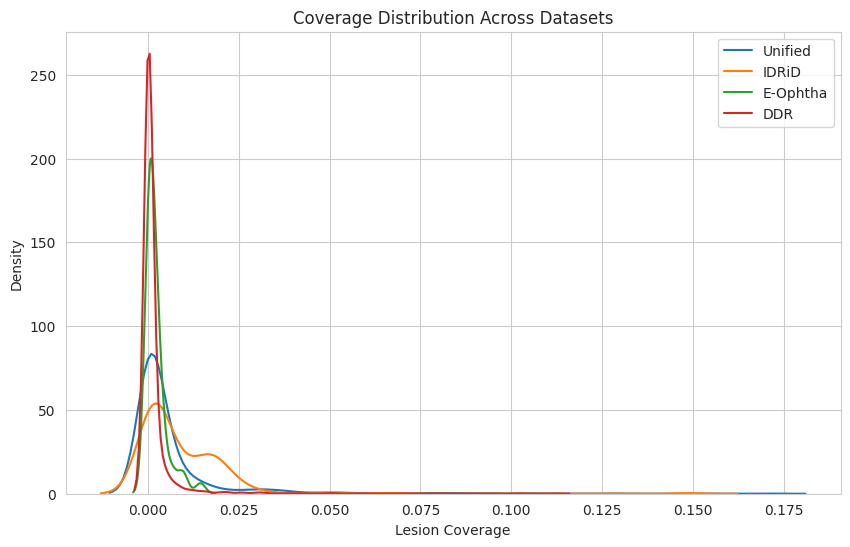

In [8]:
plt.figure(figsize=(10,6))

sns.kdeplot(unified_cov, label="Unified")
sns.kdeplot(idrid_cov, label="IDRiD")
sns.kdeplot(eophtha_cov, label="E-Ophtha")
sns.kdeplot(ddr_cov, label="DDR")

plt.title("Coverage Distribution Across Datasets")
plt.xlabel("Lesion Coverage")
plt.legend()
plt.show()

In [9]:
summary = pd.DataFrame({
    "Dataset": ["Unified", "IDRiD", "E-Ophtha", "DDR"],
    "Coverage_CV": [
        coeff_var(unified_cov),
        coeff_var(idrid_cov),
        coeff_var(eophtha_cov),
        coeff_var(ddr_cov),  # 👈 Added ['coverage'] here!
    ]
})

print(summary)

    Dataset  Coverage_CV
0   Unified     2.462101
1     IDRiD     1.482056
2  E-Ophtha     1.337936
3       DDR     3.978941
